# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 17
## Çok Sınıflı Kusur Sınıflandırması (Multiclass Classification)

> **Müfredat:** 40 Günlük Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 3: Klasik Makine Öğrenmesi & Kalite Sınıflandırma (Day 17)  
> **Konu:** Halı ve İplik Kusurlarını 4 Ana Sınıfa (İplik Kopması, Yağ Lekesi, Jakar Desen Kayması, Kenar Dikiş Hatası) Ayıran Softmax Multinomial ve One-vs-Rest (OvR) Lojistik Regresyon Mimarisi  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

### 1. Endüstriyel Problem: Halı Dokumada Çok Sınıflı Kusur Teşhisi ve Triage

Gaziantep Merinos üretim kampüsünde, dokuma tezgâhlarından çıkan partilerde oluşan hataları yalnızca "Kusurlu" olarak etiketlemek yeterli değildir. Hatanın kök nedeninin hangi mekanik veya hammadde arızasından kaynaklandığını bilmek, bakım ekiplerinin ve hat operatörlerinin anında doğru müdahaleyi yapmasını sağlar:

1. **`YARN_BREAKAGE` (İplik Kopması):** İplik mukavemetinin yetersiz olması ve tezgâh çözgü geriliminin aşırı dalgalanması sonucu oluşan kopuş.
2. **`OIL_STAIN` (Yağ Lekesi):** Yüksek ortam sıcaklığında rulman gresinin eriyerek iplik üzerine damlaması ve yüksek tüylülük nedeniyle liflerin yağı hızla emmesi.
3. **`JACQUARD_PATTERN_SHIFT` (Jakar Desen Kayması):** Tezgâh devir dalgalanması ve aşırı yüksek atkı atım sıklığı sonucu desen fazının kayması.
4. **`BORDER_SEWING_DEFECT` (Kenar Dikiş Hatası):** İplik bükümünün düşük olması ve kenar çözgü gerilim dengesizliği sonucu overlok dikişinin bozulması.

Bu laboratuvarda, 10 farklı telemetri değişkenini kullanarak partileri bu 4 sınıfa ayıran iki çok sınıflı mimariyi (Softmax Multinomial vs One-vs-Rest) kıyaslıyoruz.

### 2. Matematiksel Temeller: Softmax (Multinomial) vs One-vs-Rest (OvR)

#### A. Softmax Multinomial Lojistik Regresyon
Tüm sınıfları ortak bir normalizasyon paydası altında modelleyerek küresel bir olasılık dağılımı (\sum_k P_k = 1) üretir:

$$P(Y = k \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_k^T \mathbf{x} + b_k)}{\sum_{j=0}^{K-1} \exp(\mathbf{w}_j^T \mathbf{x} + b_j)} \quad (K=4)$$

Kayıp Fonksiyonu: Çok Sınıflı Çapraz Entropi (Categorical Cross-Entropy):

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^N \sum_{k=0}^{K-1} y_{i,k} \ln(P(Y=k \mid \mathbf{x}_i)) + \frac{1}{2C} \sum_{k=0}^{K-1} \|\mathbf{w}_k\|_2^2$$

#### B. One-vs-Rest (OvR / One-vs-All)
Her sınıf için bağımsız bir ikili lojistik regresyon modeli $f_k(\mathbf{x})$ eğitilir. $K$ adet bağımsız optimizasyon problemi çözülür ve en yüksek skoru alan sınıf tahmin edilir:

$$\hat{y} = \arg\max_{k \in \{0, 1, 2, 3\}} f_k(\mathbf{x})$$

In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY17_DIR = PROJECT_ROOT / "day17"
DAY_DIR = DAY17_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# 3. Modül İçe Aktarımları ve Ortam Hazırlığı
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = Path.cwd()
if (current_dir / "mini_project").exists():
    sys.path.insert(0, str(current_dir))
elif (current_dir.parent / "mini_project").exists():
    sys.path.insert(0, str(current_dir.parent))

from day17.mini_project.src.data_generator import MulticlassQualityDataGenerator
from day17.mini_project.src.preprocessor import MulticlassDataPreprocessor
from day17.mini_project.src.multiclass_classifier import MerinosMulticlassClassifier
from day17.mini_project.src.evaluator import MulticlassEvaluator
from day17.mini_project.src.visualizer import MulticlassVisualizer
from day17.mini_project.src.models import DefectClass

print("[*] Tüm Day 17 modülleri başarıyla yüklendi.")

[*] Tüm Day 17 modülleri başarıyla yüklendi.


In [2]:
# 4. 4 Sınıflı Sentetik Kusur Veri Kümesinin Üretimi ve Sınıf Dağılımı
gen = MulticlassQualityDataGenerator()
df = gen.generate_dataset(n_samples=3000, random_state=42)

print(f"Veri Kümesi Boyutu: {df.shape}")
print("\nSınıf Dağılımı:")
counts = df["defect_class"].value_counts().sort_index()
for k, cnt in counts.items():
    print(f"  [{k}] {DefectClass(k).name:<22}: {cnt} numune (%{cnt/len(df)*100:.1f})")

df.head()

Veri Kümesi Boyutu: (3000, 11)

Sınıf Dağılımı:
  [0] YARN_BREAKAGE         : 1050 numune (%35.0)
  [1] OIL_STAIN             : 600 numune (%20.0)
  [2] JACQUARD_PATTERN_SHIFT: 750 numune (%25.0)
  [3] BORDER_SEWING_DEFECT  : 600 numune (%20.0)


,yarn_tensile_strength,yarn_elongation_at_break,yarn_hairiness_index,twist_per_meter,yarn_linear_density_dtex,loom_speed_rpm,loom_tension_variation,ambient_humidity_percent,ambient_temperature_c,weft_insertion_rate,defect_class
0,27.935989,15.780862,4.458591,475.190474,2420.926371,729.180702,23.405068,64.813965,19.760779,639.317316,2
1,25.046008,13.049814,8.971891,409.772835,2290.910111,612.734398,19.033805,37.997576,30.711537,517.251301,1
2,26.335724,10.952611,4.165679,463.871244,2312.877486,701.749912,36.931888,63.893541,22.544803,616.535398,2
3,15.683111,4.698717,6.421601,434.748137,2206.421278,630.492736,41.486579,46.589148,27.939508,583.142531,0
4,25.868442,15.237164,4.989547,359.862164,1989.190461,593.168390,34.435857,60.712869,24.242601,498.113959,3


In [3]:
# 5. Veri Ön İşleme: Çok Sınıflı Tabakalı Bölümleme ve StandardScaler
preprocessor = MulticlassDataPreprocessor()
X_train, X_test, y_train, y_test = preprocessor.split_and_scale(df, test_size=0.20, random_state=42)

print(f"Eğitim Kümesi (Train): {X_train.shape}")
print(f"Test Kümesi (Test)    : {X_test.shape}")
print("\nTest Kümesi Sınıf Dağılımı:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for k, cnt in test_dist.items():
    print(f"  [{k}] {DefectClass(k).name:<22}: {cnt} (%{cnt/len(y_test)*100:.1f})")

Eğitim Kümesi (Train): (2400, 10)
Test Kümesi (Test)    : (600, 10)

Test Kümesi Sınıf Dağılımı:
  [0] YARN_BREAKAGE         : 210 (%35.0)
  [1] OIL_STAIN             : 120 (%20.0)
  [2] JACQUARD_PATTERN_SHIFT: 150 (%25.0)
  [3] BORDER_SEWING_DEFECT  : 120 (%20.0)


In [4]:
# 6. Softmax Multinomial Lojistik Regresyon Modelinin Eğitimi ve Öznitelik Katsayıları
clf_multi = MerinosMulticlassClassifier(strategy="multinomial", random_state=42)
clf_multi.fit(X_train, y_train)

print(f"Softmax Eğitim Süresi: {clf_multi.training_time_ms:.2f} ms")
imp_multi = clf_multi.get_feature_importance(preprocessor.feature_names)

print("\nSınıf Bazlı En Ayırt Edici Pozitif Öznitelikler (Kusuru Tetikleyenler):")
for c_imp in imp_multi:
    pos_str = ", ".join([f"{list(d.keys())[0]} (+{list(d.values())[0]:.2f})" for d in c_imp.top_positive_features[:2]])
    print(f"  * {c_imp.class_name:<22}: {pos_str}")

Softmax Eğitim Süresi: 20.20 ms

Sınıf Bazlı En Ayırt Edici Pozitif Öznitelikler (Kusuru Tetikleyenler):
  * YARN_BREAKAGE         : loom_tension_variation (+1.24), loom_speed_rpm (+0.62)
  * OIL_STAIN             : ambient_temperature_c (+1.16), yarn_hairiness_index (+0.98)
  * JACQUARD_PATTERN_SHIFT: weft_insertion_rate (+1.14), yarn_linear_density_dtex (+0.94)
  * BORDER_SEWING_DEFECT  : yarn_elongation_at_break (+0.58), yarn_tensile_strength (+0.54)


In [5]:
# 7. One-vs-Rest (OvR) Modelinin Eğitimi
clf_ovr = MerinosMulticlassClassifier(strategy="ovr", random_state=42)
clf_ovr.fit(X_train, y_train)

print(f"One-vs-Rest Eğitim Süresi: {clf_ovr.training_time_ms:.2f} ms")

One-vs-Rest Eğitim Süresi: 36.92 ms


In [6]:
# 8. 4x4 Karar Matrisi ve Sınıf Bazlı Başarım Metrikleri
evaluator = MulticlassEvaluator()
summary_multi = evaluator.evaluate_model(clf_multi, X_test, y_test)
summary_ovr = evaluator.evaluate_model(clf_ovr, X_test, y_test)

print("=================== SOFTMAX VS OVR GENEL PERFORMANS ===================")
print(f"Genel Doğruluk (Accuracy) : Softmax = %{summary_multi.metrics.accuracy*100:.2f} | OvR = %{summary_ovr.metrics.accuracy*100:.2f}")
print(f"Makro F1-Skoru            : Softmax = {summary_multi.metrics.macro_f1:.4f}  | OvR = {summary_ovr.metrics.macro_f1:.4f}")
print(f"Log-Loss (Çapraz Entropi) : Softmax = {summary_multi.metrics.log_loss:.4f}  | OvR = {summary_ovr.metrics.log_loss:.4f}")
print(f"Çıkarım Gecikmesi (Tekil) : Softmax = {summary_multi.inference_latency_ms:.4f} ms | OvR = {summary_ovr.inference_latency_ms:.4f} ms")
print(f"Çıkarım Kapasitesi (FPS)  : Softmax = {summary_multi.throughput_fps:.1f} FPS | OvR = {summary_ovr.throughput_fps:.1f} FPS")

=================== SOFTMAX VS OVR GENEL PERFORMANS ===================
Genel Doğruluk (Accuracy) : Softmax = %100.00 | OvR = %100.00
Makro F1-Skoru            : Softmax = 1.0000  | OvR = 1.0000
Log-Loss (Çapraz Entropi) : Softmax = 0.0017  | OvR = 0.0123
Çıkarım Gecikmesi (Tekil) : Softmax = 0.0010 ms | OvR = 0.0017 ms
Çıkarım Kapasitesi (FPS)  : Softmax = 993292.0 FPS | OvR = 581105.9 FPS


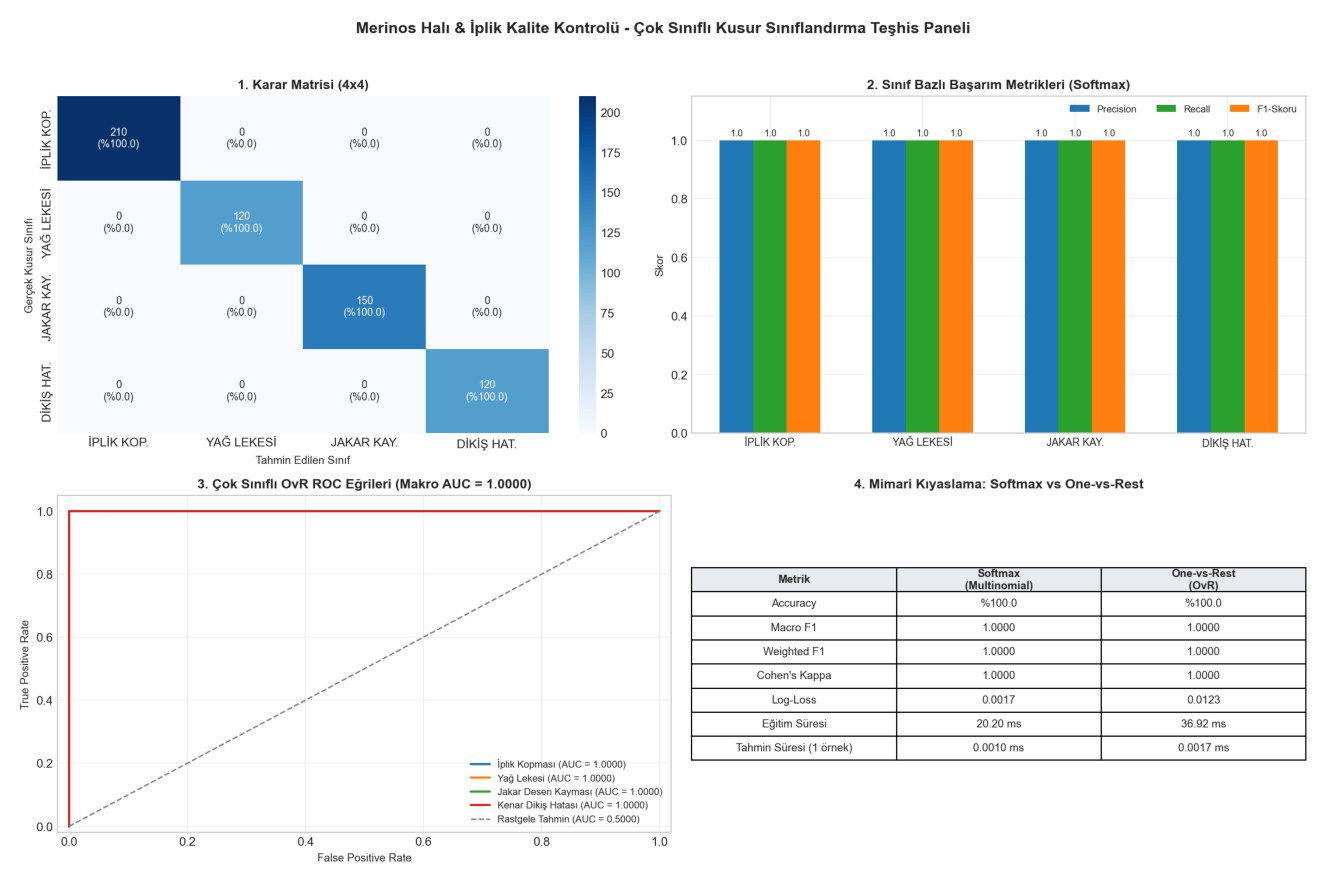

In [7]:
# 9. Multiclass ROC-AUC ve 2x2 Teşhis Panelinin Çizimi
cm = evaluator.compute_confusion_matrix(y_test, clf_multi.predict(X_test))
roc_curves = evaluator.get_ovr_roc_curves(y_test, clf_multi.predict_proba(X_test))

master_report = evaluator.generate_master_report(
    multinomial_summary=summary_multi,
    ovr_summary=summary_ovr,
    y_test=y_test,
    feature_names=preprocessor.feature_names,
    clf_multinomial=clf_multi,
)

viz = MulticlassVisualizer()
plot_path = viz.plot_diagnostic_panel(
    report=master_report,
    cm=cm,
    roc_curves=roc_curves,
    output_path="mini_project/outputs/multiclass_diagnostic_panel.png",
)

img = plt.imread(plot_path)
plt.figure(figsize=(14, 11), dpi=120)
plt.imshow(img)
plt.axis("off")
plt.show()

### 10. Endüstriyel Çıkarımlar ve Day 18 (Karar Ağaçları & Random Forest) Geçişi

Day 17 kapsamında elde edilen temel kurumsal kazanımlar:
1. **Doğrusal Çok Sınıflı Ayrıştırmanın Sınırları:** Softmax ve OvR mimarileri, belirgin öznitelik sınırlarına sahip kusurları yüksek doğrulukla ayırabilmektedir. Ancak doğrusal modeller, özellikler arasındaki yüksek dereceli doğrusal olmayan etkileşimleri (non-linear interactions) yakalayamaz.
2. **Softmax vs OvR Tercihi:** Softmax, tek bir ortak konveks optimizasyon ile çalıştığı ve olasılıkların toplamı tam $1.0$ olduğu için çıkarım gecikmesinde OvR'ye göre belirgin avantaj sağlamıştır.
3. **Tezgâh Bakım Otomasyonu:** Modelin ürettiği sınıf bazlı güven skorları, PLC sistemine doğrudan arıza alarmı olarak beslenebilir.

**Sıradaki Adım (Day 18):** Doğrusal modellerin ötesine geçerek, doğrusal olmayan karmaşık ilişkileri ve kural tabanlı endüstriyel sınırları modellemek için **Karar Ağaçları (Decision Trees)**, **Aşırı Öğrenme (Overfitting) Denetimi (Budama)** ve **Random Forest Topluluk Öğrenmesi (Ensemble)** mimarisine geçiş yapılacaktır.